In [1]:
import numpy as np
import pandas as pd
from matplotlib import pylab as plt
from sklearn.linear_model import LinearRegression
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

metadata_file = '/Users/fmcc0003/issm/projects/ISMIP6Hackathon/GroupTFtoOcean/data_analysis/Metadata_icefront.txt'
df_info = pd.read_csv(metadata_file)

computed_name = 'ComputedScalarsHelene'
mnt_pth = '/Volumes/FMac/computing/data/antarctica/' #mount path
pth_ismip6hack= mnt_pth + 'ismip6/hackathon/ComputedScalars/' #write folder
pth_ismip6 =mnt_pth + 'ismip6/hackathon/' #read folder
pth_helene =mnt_pth + 'ismip6/hackathon/ComputedScalarsHelene/'
pth_dils_table = '/Users/fmcc0003/issm/projects/ISMIP6Hackathon/GroupBMBtodSLR/data_analysis/tables/'
pth_ms_table = '/Users/fmcc0003/issm/projects/ISMIP6Hackathon/GroupTFtoOcean/data_analysis/tables/'

### Get all the data

In [2]:
colors = ['#1f77b4','#2ca02c','#9467bd']
colors2 = ['darksalmon','coral','olive']
scatters = ['.','+','^','v']

df_dils = pd.read_csv(f'{pth_dils_table}best_dils_per_model_v3.csv')
df_ms = pd.read_csv(f'{pth_ms_table}best_ms_method_per_model.csv')

In [3]:
df_dils

,Unnamed: 0,Model,calving,initialisation,resolution,meltonpartial,icefront,dils_AIS,dils_min_AIS,dils_max_AIS,...,dils_max_Ross,dils_FilchnerRonne,dils_min_FilchnerRonne,dils_max_FilchnerRonne,dils_Aurora,dils_min_Aurora,dils_max_Aurora,dils_Wilkes,dils_min_Wilkes,dils_max_Wilkes
0,0,DC_ISSM,2,DA,4km,SG,MH,0.000005,2.664618e-06,0.000006,...,0.000009,0.000006,0.000006,0.000010,0.000005,4.330829e-06,0.000006,0.000009,5.876540e-06,0.000012
1,1,DOE_MALI_4km,2,DA+,4km,FC,RO,0.000017,1.273759e-05,0.000021,...,0.000022,0.000013,0.000011,0.000021,0.000016,1.416543e-05,0.000019,0.000021,1.876798e-05,0.000022
2,2,DOE_MALI_8km_Ant95,2,DA+,8km,FC,RO,0.000017,1.451399e-05,0.000020,...,0.000028,0.000016,0.000014,0.000024,0.000020,1.668082e-05,0.000026,0.000024,2.078276e-05,0.000026
3,3,DOE_MALI_8km_AntMean,2,DA+,8km,FC,RO,0.000016,1.387823e-05,0.000019,...,0.000028,0.000015,0.000013,0.000023,0.000019,1.585274e-05,0.000022,0.000023,2.117011e-05,0.000027
4,4,IGE_ElmerIce,2,DA,1km,no,Fix,0.000003,7.231921e-07,0.000003,...,0.000004,0.000004,0.000003,0.000004,0.000002,-2.151683e-07,0.000004,0.000012,1.126977e-05,0.000012
5,5,ILTS_SICOPOLIS,2,SP+,8km,FC,MH,0.000019,1.575700e-05,0.000023,...,0.000023,0.000015,0.000013,0.000018,0.000019,1.511065e-05,0.000023,0.000022,9.544186e-06,0.000026
6,6,IMAU_UFEMISM1,2,SP+,32km,FC,Fix,0.000072,2.563163e-05,0.000127,...,0.000233,0.000117,0.000017,0.000264,0.000356,-1.234215e-05,0.001019,0.000000,-7.084270e-05,0.000000
7,7,IMAU_UFEMISM2,2,SP+,32km,FC,Fix,0.000074,3.490107e-05,0.000147,...,0.000180,0.000105,0.000023,0.000306,-0.000626,-2.913009e-03,-0.000025,0.000000,-9.797594e-05,0.000000
8,8,IMAU_UFEMISM3,2,SP+,16km,FC,Fix,0.000060,4.078930e-05,0.000110,...,0.000111,0.000059,0.000025,0.000166,0.000113,-1.005359e-05,0.000154,-0.000078,-3.228193e-03,0.000001
9,9,IMAU_UFEMISM4,2,SP+,16km,FC,Fix,0.000061,4.120245e-05,0.000117,...,0.000102,0.000062,0.000027,0.000487,0.000095,6.795913e-05,0.000137,-0.000016,-1.969651e-03,0.000050


In [4]:
df_ms

,Unnamed: 0,Model,mean-error,method,parameterization,melt_sensetivity_AIS,melt_sensetivity_intercept_AIS,melt_sensetivity_Amundsen,melt_sensetivity_intercept_Amundsen,melt_sensetivity_Ross,melt_sensetivity_intercept_Ross,melt_sensetivity_FilchnerRonne,melt_sensetivity_intercept_FilchnerRonne,melt_sensetivity_Aurora,melt_sensetivity_intercept_Aurora,melt_sensetivity_Wilkes,melt_sensetivity_intercept_Wilkes
0,0,DC_ISSM,1.126875,df_maxbmb,Quad. Non-local,3.940746,-1.694661,8.640169,-3.372736,3.354130,-1.536894,4.269001,-1.984396,6.983680,-2.124761,6.423657,-3.994535
1,1,DOE_MALI_4km,1.542692,df_maxbmb,Quad. Non-local,7.091286,-4.422678,18.827810,-17.018395,4.042975,-1.908087,5.389555,-2.404711,9.581578,-2.970956,10.618707,-7.781417
2,2,DOE_MALI_8km_Ant95,1.609465,df_maxbmb,Quad. Non-local,10.636001,-8.527297,21.835821,-23.217318,4.302845,-1.895368,6.010999,-2.553659,11.298475,-4.911402,13.488096,-10.237464
3,3,DOE_MALI_8km_AntMean,1.336166,df_maxbmb,Quad. Non-local,6.905944,-3.671605,17.703470,-16.183663,4.345924,-2.012370,6.094617,-2.850230,10.741955,-4.673022,11.403571,-8.562308
4,4,IGE_ElmerIce,1.822429,df_maxbmb,PICO,1.887178,0.270598,2.611416,8.705787,1.570026,-0.379978,1.837577,-1.078901,8.152143,0.464576,7.746371,-0.735873
5,5,ILTS_SICOPOLIS,1.855219,df_maxbmb,Quad. Non-local,9.529746,-7.334161,19.867998,-14.139391,4.215458,-1.940084,5.730758,-2.780314,9.565332,-1.560262,11.426381,-7.366425
6,6,LSCE_GRISLI2,1.479912,df_maxbmb,Quad. Non-local,5.442525,-2.596553,17.034515,-12.135003,3.643000,-1.662566,4.935931,-2.318317,7.970280,-1.027697,8.469353,-4.225666
7,7,LSCE_GRISLI,1.517942,df_maxbmb,Quad. Non-local,5.507551,-2.621882,17.728342,-13.573608,3.606178,-1.647675,5.148203,-2.499429,8.673908,-1.482538,9.330892,-5.637042
8,8,NCAR_CISM1,1.399016,df_maxbmb,Quad. Non-local,3.792347,-1.423690,6.875624,-9.698237,3.831562,-1.801018,4.972992,-2.467405,2.365846,-3.200780,5.339243,-3.602602
9,9,NCAR_CISM2,1.702342,df_maxbmb,Quad. Local,5.509823,-2.209888,11.917042,-12.972440,4.581646,-1.519366,6.870203,-2.637447,7.991848,-2.447761,7.707624,-2.205806


In [5]:
np.where(df_ms['melt_sensetivity_AIS'] == df_ms['melt_sensetivity_AIS'].min())

(array([24]),)

In [6]:
df_ms['Model'].iloc[24]

'ULB_fETISh-KoriBU1'

In [7]:
np.mean(np.sort(df_ms['melt_sensetivity_FilchnerRonne'])[-10:])

17.171180475282384

In [8]:
np.mean(np.sort(df_ms['melt_sensetivity_FilchnerRonne'])[:10])

3.1613071088439404

## Plot the main figure

#### Exclude some dodgy models

In [9]:
df_ms_new = df_ms.copy()
df_dils_new = df_dils.copy()
# removekeys = ['VUB_AISMPALEO', 'IMAU_UFEMISM1', 'IMAU_UFEMISM2', 'IMAU_UFEMISM3', 'IMAU_UFEMISM4',
#              'VUW_PISM1', 'VUW_PISM1_s1', 'VUW_PISM1_s2', 'VUW_PISM1_s3', 'VUW_PISM1_s4',
#              'VUW_PISM2', 'VUW_PISM2_s1', 'VUW_PISM2_s2', 'VUW_PISM2_s3', 'VUW_PISM2_s4']
removekeys = ['VUB_AISMPALEO', 'VUW_PISM1_s1', 'IMAU_UFEMISM1', 'IMAU_UFEMISM2', 'IMAU_UFEMISM3', 'IMAU_UFEMISM4']
for i,key in enumerate(removekeys):
    df_ms_new = df_ms_new.drop(np.where(df_ms_new.Model.values==key)[0][0]).reset_index(drop=True)
    df_dils_new = df_dils_new.drop(np.where(df_dils_new.Model.values==key)[0][0]).reset_index(drop=True)

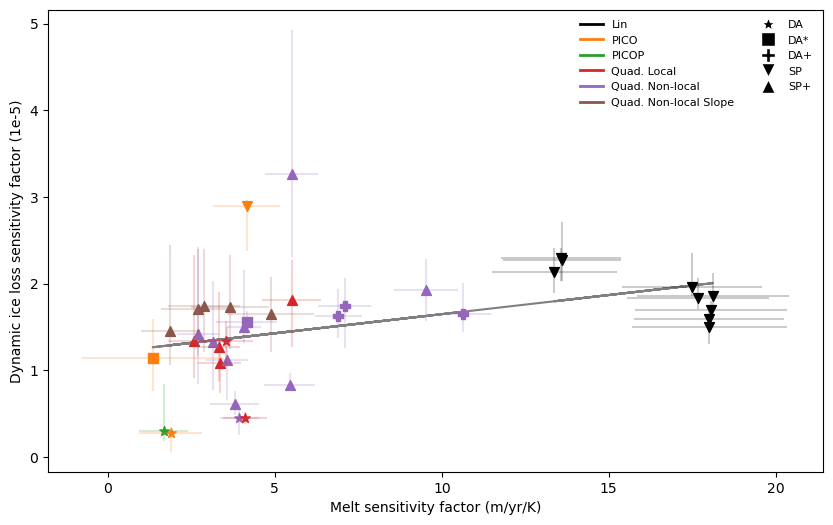

In [14]:
marker_key = 'initialisation'
#marker_key = 'calving'
#marker_key = 'meltonpartial'
#marker_key = 'icefront'
#marker_key = 'resolution'

exclude_pism = 0

# set up the markers
marker_field_u = np.unique(df_dils_new[marker_key])
marker_u = ['*','s','P','v','^','p']
dic_marker = {}
for i,key in enumerate(marker_field_u):
    dic_marker[key]= marker_u[i]
markers = []
marker_nomodel=[]
msk = df_dils_new.Model.values != 'VUW_PISM2_s1'

for key in df_dils_new[marker_key]:
    markers.append(dic_marker[key])

for key in df_dils_new[marker_key][msk]:
    marker_nomodel.append(dic_marker[key])

# set up the colours
color_key = 'parameterization'
color_field_u = np.unique(df_ms_new[color_key])
color_u = ['black', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
dic_color = {}
for i,key in enumerate(color_field_u):
    dic_color[key]= color_u[i]
colors = []
color_nomodel=[]
msk = df_ms_new.Model.values != 'VUW_PISM2_s1'

for key in df_ms_new[color_key]:
    colors.append(dic_color[key])

for key in df_ms_new[color_key][msk]:
    color_nomodel.append(dic_color[key])

# plot the thing
f,ax = plt.subplots(1,1,figsize =(10,6))

xms = df_ms_new['melt_sensetivity_AIS'].values
xr = df_ms_new['mean-error'].values
xl = xms-xr/2
xu = xms+xr/2

ydils = df_dils_new['dils_AIS'].values*1e5
yl = df_dils_new['dils_min_AIS'].values*1e5
yu = df_dils_new['dils_max_AIS'].values*1e5

x_reshape = xms.reshape(-1, 1)
model = LinearRegression()
model.fit(x_reshape, ydils)
y_pred = model.predict(x_reshape)
plt.plot(xms, y_pred, label='linregress', zorder=-1, color='gray',linestyle='-')

for i in range(len(xms)):
    plt.scatter(xms[i], ydils[i], marker=markers[i], color=colors[i], s=50)
    plt.plot([xms[i],xms[i]], [yl[i],yu[i]], alpha=0.2, color=colors[i])
    plt.plot([xl[i],xu[i]], [ydils[i],ydils[i]], alpha=0.2, color=colors[i])

ci = len(color_field_u)
mi = len(marker_field_u)
color_handles = [Line2D([0], [0], color=color, lw=2) for color in color_u[:ci]]
marker_handles = [Line2D([0], [0], marker=marker, color='w', markerfacecolor='k', markersize=10) for marker in marker_u[:mi]]
custom_handles = color_handles + marker_handles
custom_labels = list(color_field_u) + list(marker_field_u)
ax.legend(handles=custom_handles, labels=custom_labels,
         loc='upper right', bbox_to_anchor=(1, 1), ncol=2, frameon=False, fontsize = 8)

ax.set_xlabel('Melt sensitivity factor (m/yr/K)')
ax.set_ylabel('Dynamic ice loss sensitivity factor (1e-5)') ##TODO: Check units

if exclude_pism == 1:
    f.savefig(f'/Volumes/FMac/computing/data/antarctica/ismip6/hackathon/figures/ms_dils_AIS_{marker_key}_novuwpism.pdf', bbox_inches='tight')
    f.savefig(f'/Volumes/FMac/computing/data/antarctica/ismip6/hackathon/figures/ms_dils_AIS_{marker_key}_novuwpism.jpeg', bbox_inches='tight')    
else:
    f.savefig(f'/Volumes/FMac/computing/data/antarctica/ismip6/hackathon/figures/ms_dils_AIS_{marker_key}.pdf', bbox_inches='tight')
    f.savefig(f'/Volumes/FMac/computing/data/antarctica/ismip6/hackathon/figures/ms_dils_AIS_{marker_key}.jpeg', bbox_inches='tight')

In [21]:
model.coef_[0]

0.04413399810330519

In [24]:
model.intercept_

1.206548171202261

In [27]:
model.score(x_reshape,ydils)

0.15695935193890576